In [2]:
import os
os.environ['PROJ_DATA'] = '/opt/sw/anaconda3/2023.09/envs/pangeo23/share/proj'
os.environ['PROJ_LIB']  = '/opt/sw/anaconda3/2023.09/envs/pangeo23/share/proj'
 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import netCDF4 as nc
import glob
import warnings
from scipy import stats
import cartopy.crs as ccrs
import cartopy.feature as cfeature
 
warnings.filterwarnings('ignore')
print("✅ 所有库导入成功！")

✅ 所有库导入成功！


In [3]:
data_dir = os.path.expanduser('~/Final Project Computing/data/MODIS')
hdf_files = sorted(glob.glob(os.path.join(data_dir, '*.hdf')))
n_files   = len(hdf_files)
print(f"找到 {n_files} 个HDF文件")
 
# 全球grid: 3600行(90°N→90°S), 7200列(180°W→180°E), 分辨率0.05°
# 美国大陆范围: 纬度24-50°N, 经度125-66°W
lat_min, lat_max =  24,   50
lon_min, lon_max = -125, -66
 
row_start = int((90 - lat_max) / 0.05)   # 800
row_end   = int((90 - lat_min) / 0.05)   # 1320
col_start = int((lon_min + 180) / 0.05)  # 1100
col_end   = int((lon_max + 180) / 0.05)  # 2280
 
n_lat = row_end - row_start
n_lon = col_end - col_start
 
# 生成经纬度坐标
lats = np.arange(90, -90, -0.05)[row_start:row_end]
lons = np.arange(-180, 180, 0.05)[col_start:col_end]
 
print(f"网格大小: {n_lat} × {n_lon}")
print(f"纬度范围: {lats[-1]:.1f}°N ~ {lats[0]:.1f}°N")
print(f"经度范围: {lons[0]:.1f}°E ~ {lons[-1]:.1f}°E")

找到 281 个HDF文件
网格大小: 520 × 1180
纬度范围: 24.1°N ~ 50.0°N
经度范围: -125.0°E ~ -66.0°E


In [4]:
def parse_date(filepath):
    """从文件名提取年月，如 MOD10CM.A2000061 → 2000-03-01"""
    basename = os.path.basename(filepath)
    year = int(basename[9:13])
    doy  = int(basename[13:16])
    date = pd.Timestamp(year=year, month=1, day=1) + pd.Timedelta(days=doy - 1)
    return date
 
print(f"第一个文件日期: {parse_date(hdf_files[0]).strftime('%Y-%m')}")
print(f"最后一个文件日期: {parse_date(hdf_files[-1]).strftime('%Y-%m')}")

第一个文件日期: 2000-03
最后一个文件日期: 2023-12


In [5]:
# MODIS MOD10CM 特殊值说明:
#   0-100 = 积雪覆盖百分比（有效数据）
#   211   = 夜晚
#   250   = 云覆盖
#   253   = 无法判断
#   254   = 水体
#   255   = 填充值（无数据）
INVALID = [211, 250, 253, 254, 255]
 
snow_all = np.full((n_files, n_lat, n_lon), np.nan, dtype=np.float32)
dates    = []
 
print("开始读取文件...")
for i, fpath in enumerate(hdf_files):
    f   = nc.Dataset(fpath, 'r')
    raw = f.variables['Snow_Cover_Monthly_CMG'][row_start:row_end, col_start:col_end]
    f.close()
 
    data = np.array(raw, dtype=np.float32)
    for val in INVALID:
        data[data == val] = np.nan
    data[data > 100] = np.nan   # 额外保险
 
    snow_all[i] = data
    dates.append(parse_date(fpath))
 
    if (i + 1) % 50 == 0:
        print(f"  已处理 {i+1}/{n_files} 个文件")
 
dates = pd.DatetimeIndex(dates)
 
# 验证
print(f"\n✅ 读取完成！")
print(f"数组形状: {snow_all.shape}  (时间, 纬度, 经度)")
print(f"NaN比例:  {np.isnan(snow_all[0]).mean():.2%}  （海洋+无效区域）")
print(f"数值范围: {np.nanmin(snow_all):.1f} ~ {np.nanmax(snow_all):.1f} %")

开始读取文件...
  已处理 50/281 个文件
  已处理 100/281 个文件
  已处理 150/281 个文件
  已处理 200/281 个文件
  已处理 250/281 个文件

✅ 读取完成！
数组形状: (281, 520, 1180)  (时间, 纬度, 经度)
NaN比例:  31.62%  （海洋+无效区域）
数值范围: 0.0 ~ 100.0 %


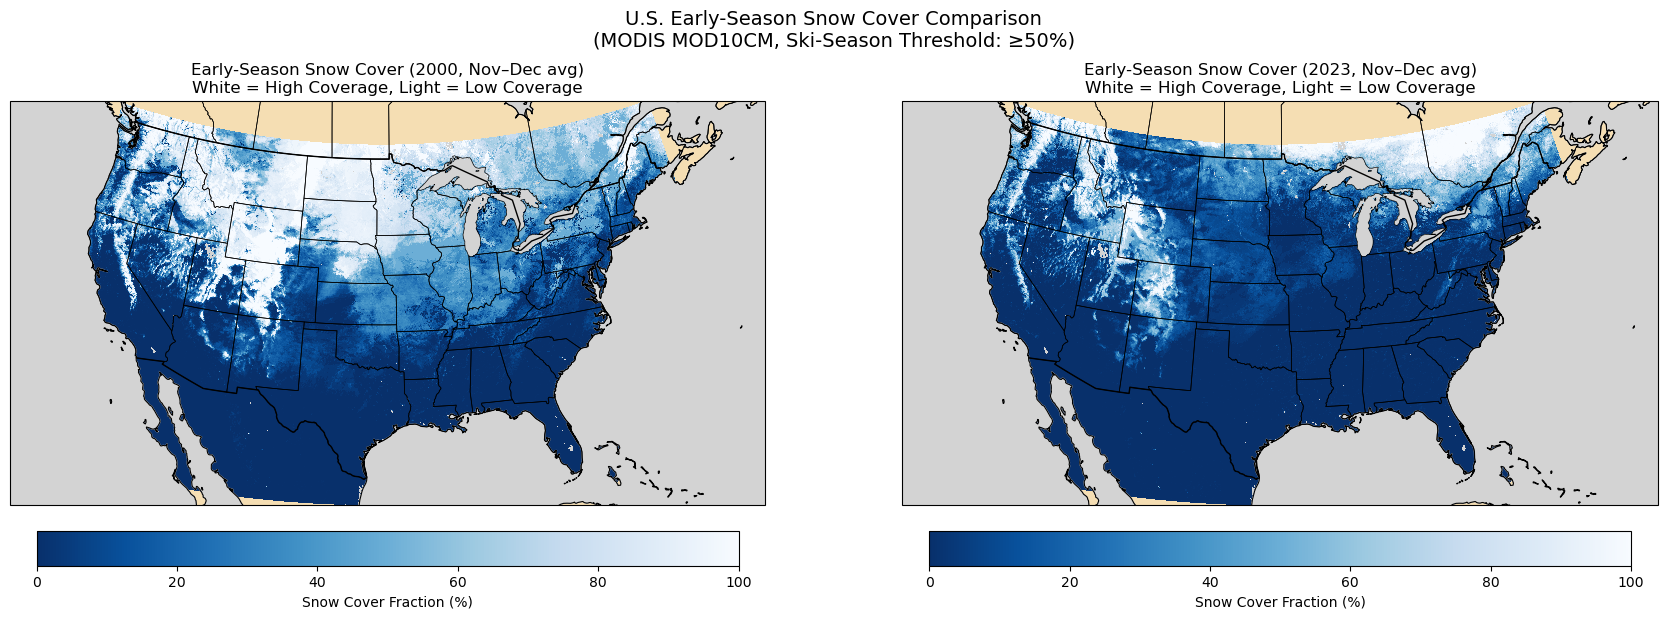

In [7]:
# 选11月和12月数据（早季）
idx_2000_nov = np.where((dates.year == 2000) & (dates.month == 11))[0]
idx_2023_nov = np.where((dates.year == 2023) & (dates.month == 11))[0]
idx_2000_dec = np.where((dates.year == 2000) & (dates.month == 12))[0]
idx_2023_dec = np.where((dates.year == 2023) & (dates.month == 12))[0]

# 用11-12月平均
snow_2000_early = np.nanmean(snow_all[np.concatenate([idx_2000_nov, idx_2000_dec])], axis=0)
snow_2023_early = np.nanmean(snow_all[np.concatenate([idx_2023_nov, idx_2023_dec])], axis=0)

SKI_THRESHOLD = 50  # ≥50% 视为可滑雪覆盖

cmap_snow = plt.cm.Blues_r
cmap_snow.set_bad(color='lightgray')

fig, axes = plt.subplots(1, 2, figsize=(18, 6),
    subplot_kw={'projection': ccrs.LambertConformal(
        central_longitude=-96, central_latitude=39)})

for ax, data, year in zip(axes, [snow_2000_early, snow_2023_early], [2000, 2023]):
    im = ax.pcolormesh(lons, lats, data,
                       transform=ccrs.PlateCarree(),
                       cmap=cmap_snow, vmin=0, vmax=100)
    ax.add_feature(cfeature.OCEAN,     color='lightgray', zorder=1)
    ax.add_feature(cfeature.LAND,      color='wheat',     zorder=0)
    ax.add_feature(cfeature.STATES,    linewidth=0.5,     zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8,     zorder=2)
    ax.add_feature(cfeature.BORDERS,   linewidth=1.0,     zorder=2)
    ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())
    ax.set_title(f'Early-Season Snow Cover ({year}, Nov–Dec avg)\n'
                 f'White = High Coverage, Light = Low Coverage', fontsize=12)
    plt.colorbar(im, ax=ax, label='Snow Cover Fraction (%)',
                 orientation='horizontal', pad=0.05, shrink=0.8)

plt.suptitle('U.S. Early-Season Snow Cover Comparison\n'
             f'(MODIS MOD10CM, Ski-Season Threshold: ≥{SKI_THRESHOLD}%)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('snow_comparison_early_season.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
years = np.arange(2000, 2024)
winter_annual = np.full((len(years), n_lat, n_lon), np.nan, dtype=np.float32)
 
for i, yr in enumerate(years):
    if yr == 2000:
        mask = (dates.year == yr) & (dates.month.isin([3]))
    else:
        mask = ((dates.year == yr)   & (dates.month.isin([1, 2, 3]))) | \
               ((dates.year == yr-1) & (dates.month == 12))
    if mask.sum() > 0:
        winter_annual[i] = np.nanmean(snow_all[mask], axis=0)
 
print(f"✅ 年均冬季积雪数组: {winter_annual.shape}  (年份, 纬度, 经度)")

✅ 年均冬季积雪数组: (24, 520, 1180)  (年份, 纬度, 经度)


In [42]:
print("计算趋势图，请稍候...")
 
slope_map = np.full((n_lat, n_lon), np.nan)
pval_map  = np.full((n_lat, n_lon), np.nan)
 
for i in range(n_lat):
    for j in range(n_lon):
        y     = winter_annual[:, i, j]
        valid = ~np.isnan(y)
        if valid.sum() >= 10:
            slope, _, _, pval, _ = stats.linregress(years[valid], y[valid])
            slope_map[i, j] = slope
            pval_map[i, j]  = pval
 
print("✅ 趋势计算完成！")
print(f"趋势范围: {np.nanmin(slope_map):.3f} ~ {np.nanmax(slope_map):.3f} %/year")

计算趋势图，请稍候...
✅ 趋势计算完成！
趋势范围: -2.288 ~ 2.615 %/year


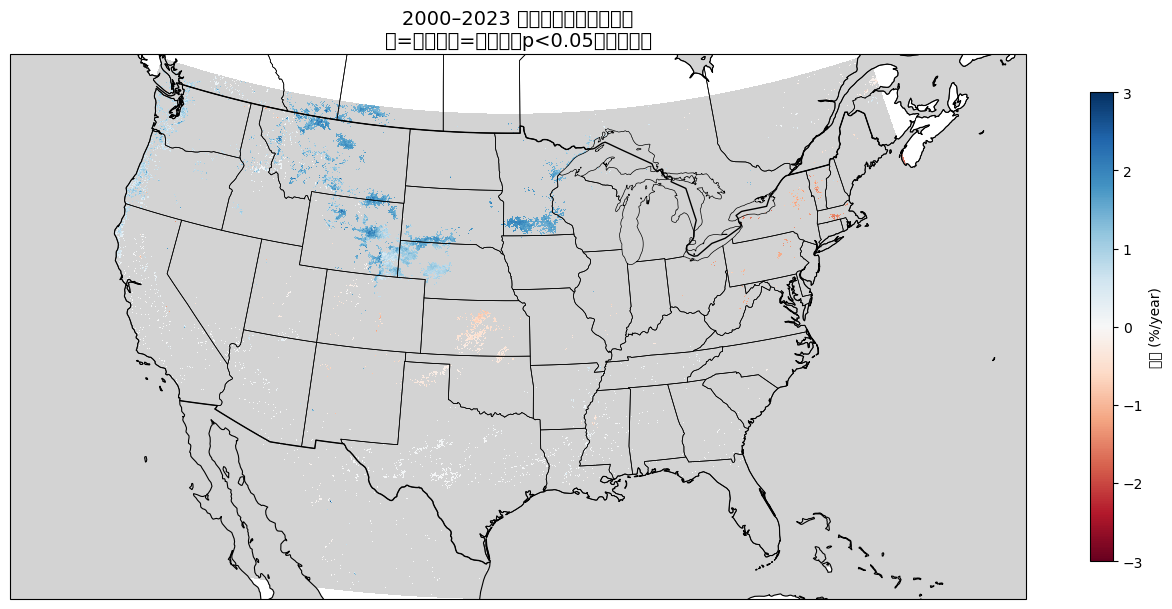

✅ 图片已保存: snow_trend_map.png


In [44]:
slope_sig = np.where(pval_map < 0.05, slope_map, np.nan)
 
cmap_trend = plt.cm.RdBu
cmap_trend.set_bad(color='lightgray')
 
fig, ax = plt.subplots(figsize=(13, 7),
    subplot_kw={'projection': ccrs.LambertConformal(
        central_longitude=-96, central_latitude=39)})
 
im = ax.pcolormesh(lons, lats, slope_sig,
                   transform=ccrs.PlateCarree(),
                   cmap=cmap_trend, vmin=-3, vmax=3)
 
ax.add_feature(cfeature.OCEAN,    color='lightgray', zorder=1)
ax.add_feature(cfeature.STATES,   linewidth=0.5,     zorder=2)
ax.add_feature(cfeature.COASTLINE,linewidth=0.8,     zorder=2)
ax.add_feature(cfeature.BORDERS,  linewidth=1.0,     zorder=2)
ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())
ax.set_title('2000–2023 美国冬季积雪覆盖趋势\n蓝=增加，红=减少（仅p<0.05显著区域）', fontsize=14)
plt.colorbar(im, ax=ax, label='趋势 (%/year)', shrink=0.7)
 
plt.tight_layout()
plt.savefig('snow_trend_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 图片已保存: snow_trend_map.png")

✅ 积雪季节长度数组: (24, 520, 1180)


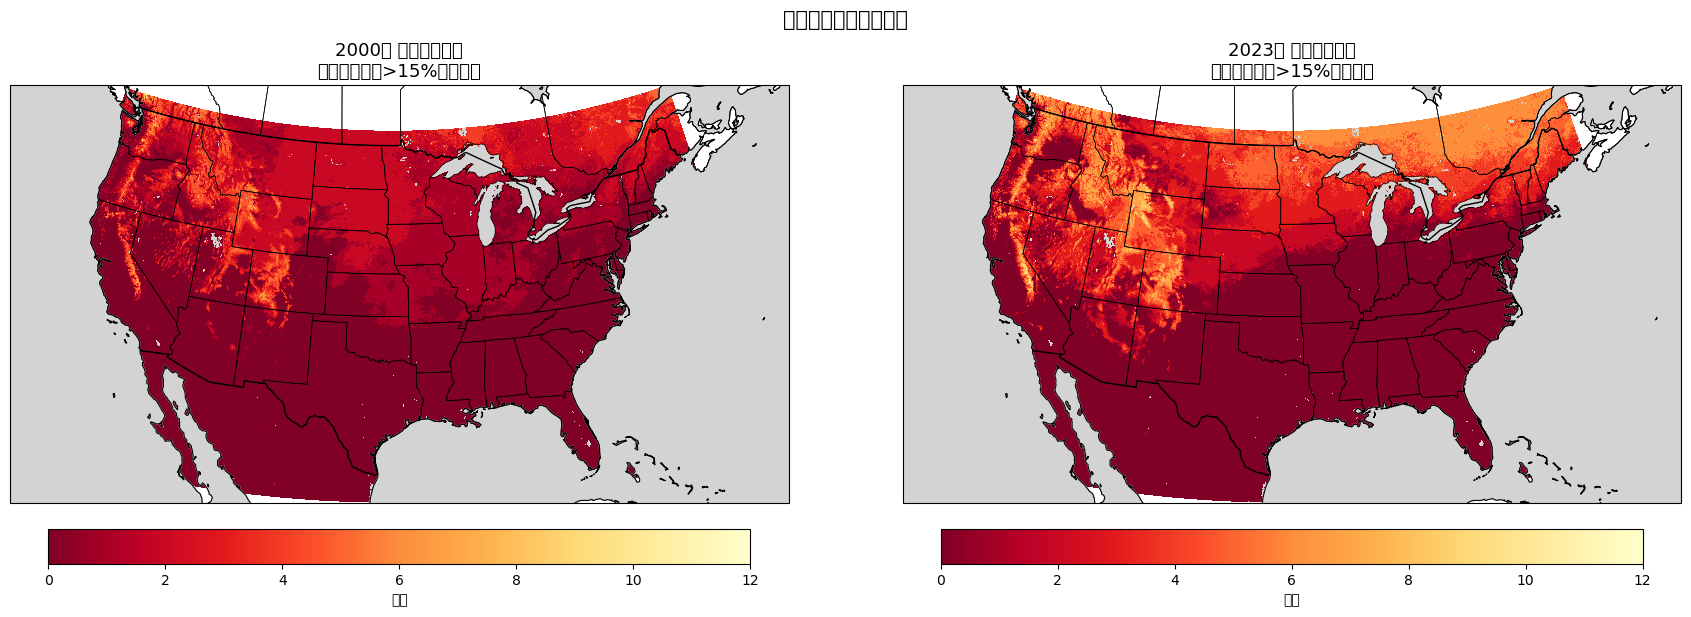

✅ 图片已保存: season_length_comparison.png


In [9]:
threshold     = 50
season_length = np.full((len(years), n_lat, n_lon), np.nan, dtype=np.float32)
 
for i, yr in enumerate(years):
    mask    = dates.year == yr
    yr_data = snow_all[mask]
    sl      = np.nansum(yr_data > threshold, axis=0).astype(np.float32)
    all_nan = np.all(np.isnan(yr_data), axis=0)
    sl[all_nan] = np.nan
    season_length[i] = sl
 
print(f"✅ 积雪季节长度数组: {season_length.shape}")
 
# 2000 vs 2023 对比图
cmap_sl = plt.cm.YlOrRd_r
cmap_sl.set_bad(color='lightgray')
 
fig, axes = plt.subplots(1, 2, figsize=(18, 6),
    subplot_kw={'projection': ccrs.LambertConformal(
        central_longitude=-96, central_latitude=39)})
 
for ax, i, yr in zip(axes, [0, 23], [2000, 2023]):
    im = ax.pcolormesh(lons, lats, season_length[i],
                       transform=ccrs.PlateCarree(),
                       cmap=cmap_sl, vmin=0, vmax=12)
    ax.add_feature(cfeature.OCEAN,    color='lightgray', zorder=1)
    ax.add_feature(cfeature.STATES,   linewidth=0.5,     zorder=2)
    ax.add_feature(cfeature.COASTLINE,linewidth=0.8,     zorder=2)
    ax.add_feature(cfeature.BORDERS,  linewidth=1.0,     zorder=2)
    ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())
    ax.set_title(f'{yr}年 积雪季节长度\n（积雪覆盖率>15%的月数）', fontsize=13)
    plt.colorbar(im, ax=ax, label='月数', orientation='horizontal',
                 pad=0.05, shrink=0.8)
 
plt.suptitle('美国积雪季节长度对比', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('season_length_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 图片已保存: season_length_comparison.png")

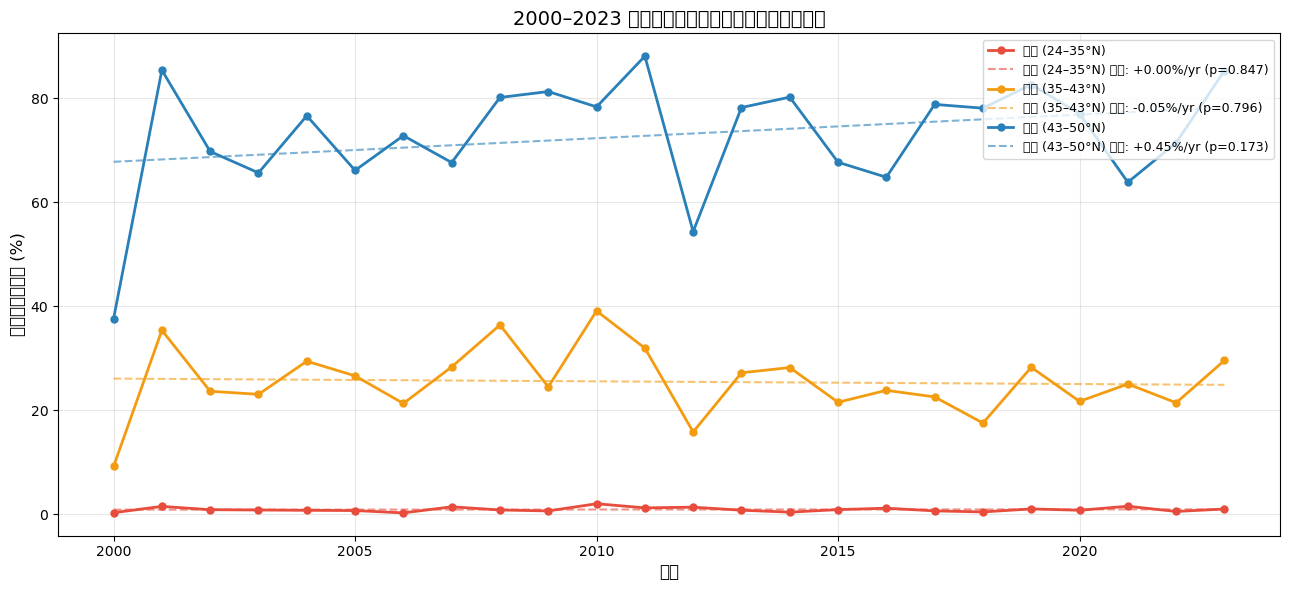

✅ 图片已保存: snow_timeseries_by_latitude.png


In [46]:
regions = {
    '低纬 (24–35°N)': (lats >= 24) & (lats < 35),
    '中纬 (35–43°N)': (lats >= 35) & (lats < 43),
    '高纬 (43–50°N)': (lats >= 43) & (lats <= 50),
}
colors = ['#e74c3c', '#f39c12', '#2980b9']
 
fig, ax = plt.subplots(figsize=(13, 6))
 
for (label, lat_mask), color in zip(regions.items(), colors):
    ts = np.array([
        np.nanmean(winter_annual[i, lat_mask, :]) for i in range(len(years))
    ])
    ax.plot(years, ts, 'o-', color=color, label=label, linewidth=2, markersize=5)
 
    # 加趋势线
    valid = ~np.isnan(ts)
    if valid.sum() >= 5:
        slope, intercept, r, p, _ = stats.linregress(years[valid], ts[valid])
        ax.plot(years, slope * years + intercept, '--', color=color, alpha=0.6,
                label=f'{label} 趋势: {slope:+.2f}%/yr (p={p:.3f})')
 
ax.set_xlabel('年份', fontsize=12)
ax.set_ylabel('平均积雪覆盖率 (%)', fontsize=12)
ax.set_title('2000–2023 美国各纬度带冬季积雪覆盖率时间序列', fontsize=14)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('snow_timeseries_by_latitude.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 图片已保存: snow_timeseries_by_latitude.png")

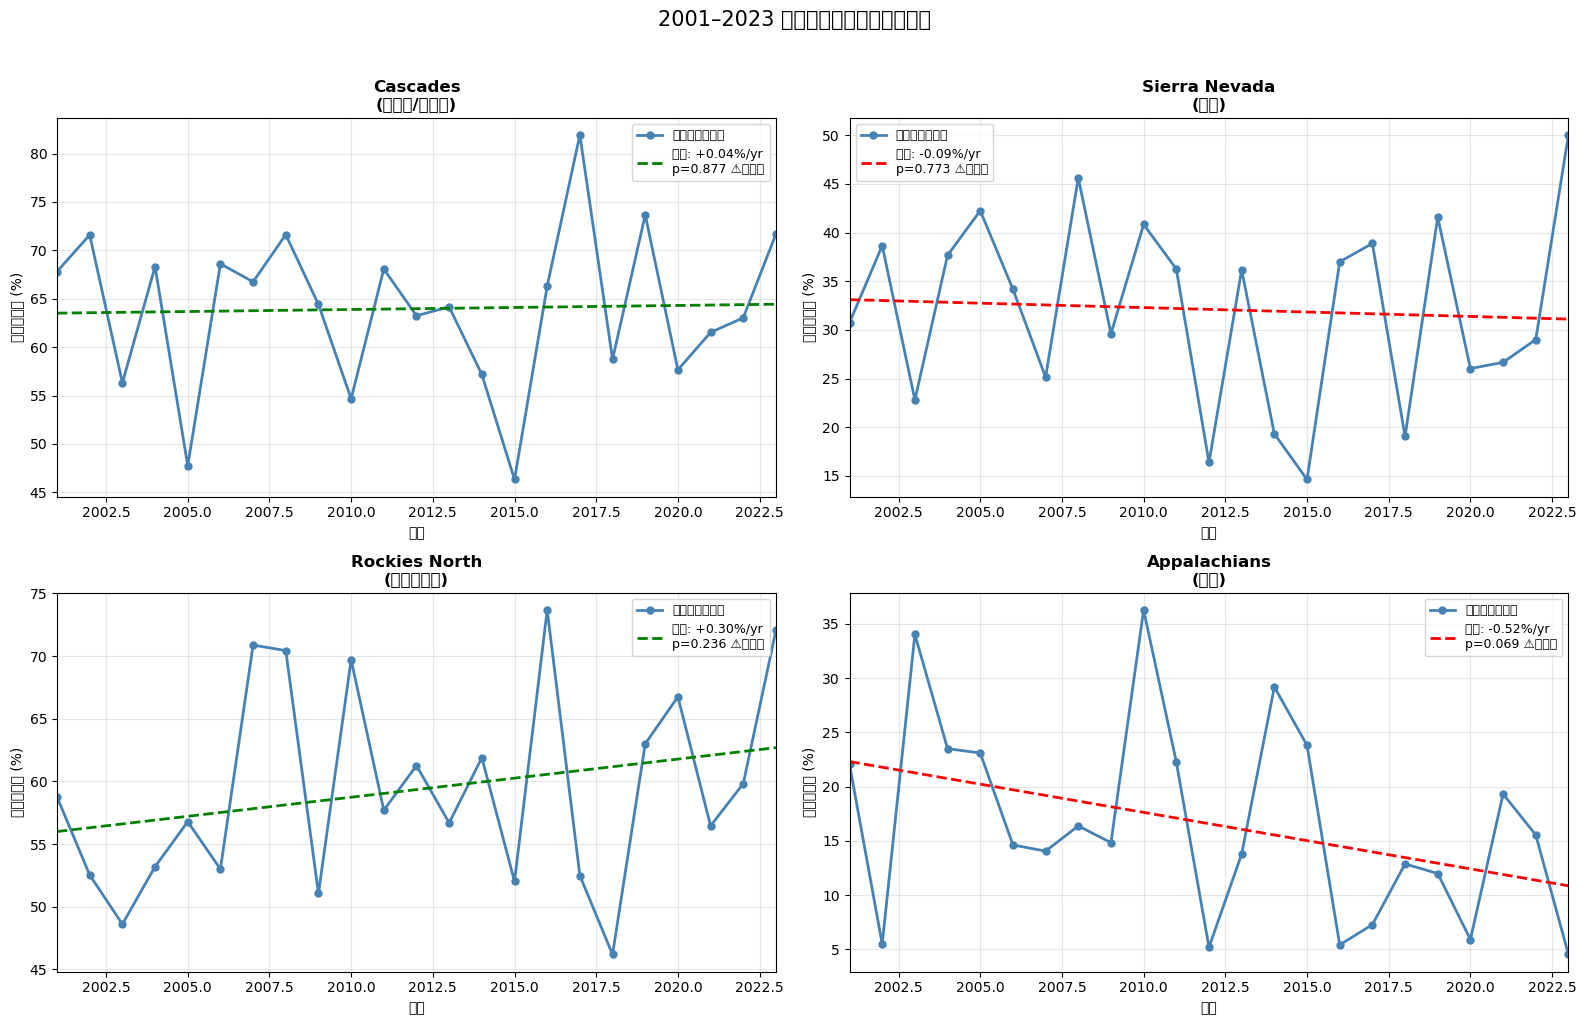

In [47]:
# ── 改进版时间序列：聚焦山脉区域 + 修复2000年问题 ──

# 定义主要滑雪山脉区域（经纬度范围）
ski_regions = {
    'Cascades\n(华盛顿/俄勒冈)':  {'lat': (45, 49), 'lon': (-122, -120)},
    'Sierra Nevada\n(加州)':       {'lat': (36, 42), 'lon': (-121, -118)},
    'Rockies North\n(科罗拉多北)': {'lat': (39, 42), 'lon': (-107, -104)},
    'Appalachians\n(东部)':        {'lat': (36, 42), 'lon': (-82,  -76)},
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# 从2001年开始（避免2000年数据不完整的问题）
years_plot = years[1:]  # 2001-2023

for ax, (region_name, bounds) in zip(axes, ski_regions.items()):
    lat_mask = (lats >= bounds['lat'][0]) & (lats <= bounds['lat'][1])
    lon_mask = (lons >= bounds['lon'][0]) & (lons <= bounds['lon'][1])

    ts = np.array([
        np.nanmean(winter_annual[i][np.ix_(lat_mask, lon_mask)])
        for i in range(1, len(years))  # 从index 1开始，跳过2000年
    ])

    # 画时间序列
    ax.plot(years_plot, ts, 'o-', color='steelblue',
            linewidth=2, markersize=5, label='年均积雪覆盖率')

    # 趋势线
    valid = ~np.isnan(ts)
    if valid.sum() >= 5:
        slope, intercept, r, p, _ = stats.linregress(years_plot[valid], ts[valid])
        trend_line = slope * years_plot + intercept
        color = 'red' if slope < 0 else 'green'
        ax.plot(years_plot, trend_line, '--', color=color, linewidth=2,
                label=f'趋势: {slope:+.2f}%/yr\np={p:.3f} {"✅显著" if p<0.05 else "⚠️不显著"}')

    ax.set_title(region_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('年份')
    ax.set_ylabel('积雪覆盖率 (%)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(2001, 2023)

plt.suptitle('2001–2023 美国主要滑雪山脉积雪趋势', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('ski_region_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

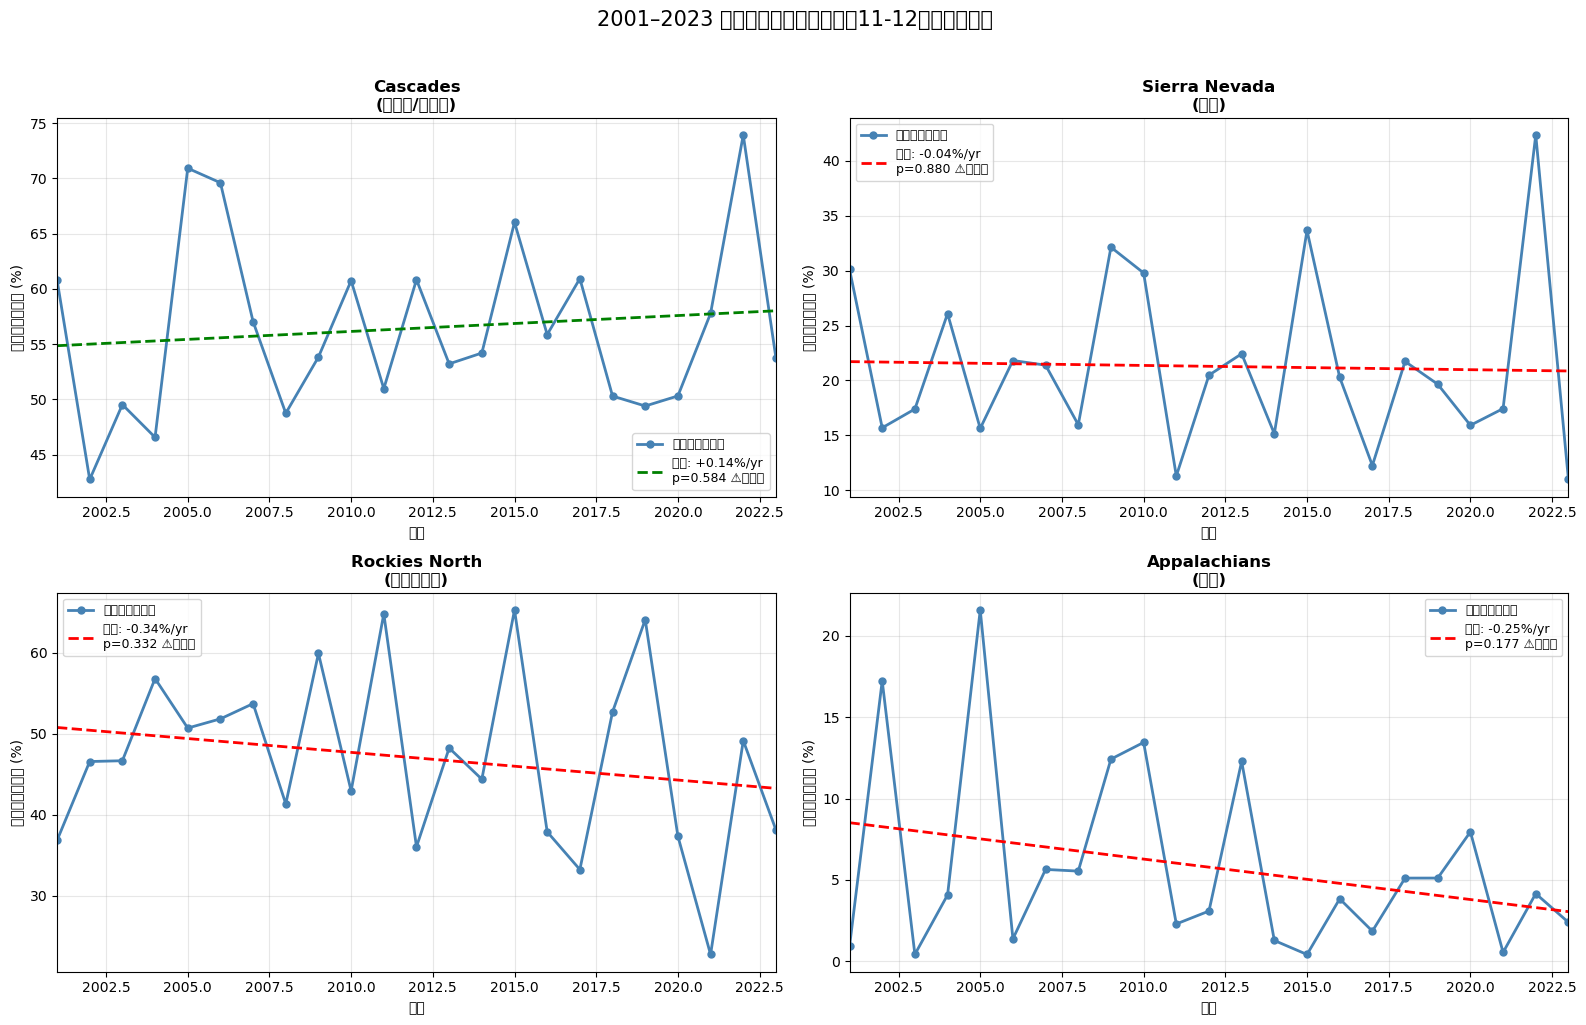

In [48]:
# 只看11月+12月（滑雪季开始时间）
early_season_annual = np.full((len(years), n_lat, n_lon), np.nan, dtype=np.float32)

for i, yr in enumerate(years):
    # 11月和12月
    mask = (dates.year == yr) & (dates.month.isin([11, 12]))
    if mask.sum() > 0:
        early_season_annual[i] = np.nanmean(snow_all[mask], axis=0)

# 画同样的4个区域时间序列
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

years_plot = years[1:]  # 从2001开始

for ax, (region_name, bounds) in zip(axes, ski_regions.items()):
    lat_mask = (lats >= bounds['lat'][0]) & (lats <= bounds['lat'][1])
    lon_mask = (lons >= bounds['lon'][0]) & (lons <= bounds['lon'][1])

    ts = np.array([
        np.nanmean(early_season_annual[i][np.ix_(lat_mask, lon_mask)])
        for i in range(1, len(years))
    ])

    ax.plot(years_plot, ts, 'o-', color='steelblue',
            linewidth=2, markersize=5, label='早季积雪覆盖率')

    valid = ~np.isnan(ts)
    if valid.sum() >= 5:
        slope, intercept, r, p, _ = stats.linregress(years_plot[valid], ts[valid])
        color = 'red' if slope < 0 else 'green'
        ax.plot(years_plot, slope * years_plot + intercept, '--',
                color=color, linewidth=2,
                label=f'趋势: {slope:+.2f}%/yr\np={p:.3f} {"✅显著" if p<0.05 else "⚠️不显著"}')

    ax.set_title(region_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('年份')
    ax.set_ylabel('早季积雪覆盖率 (%)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(2001, 2023)

plt.suptitle('2001–2023 美国主要滑雪山脉早季（11-12月）积雪趋势', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('ski_early_season_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

In [49]:
# ── Cell 7: 逐像素线性趋势（针对早季）──
print("计算早季趋势图，请稍候...")

slope_map = np.full((n_lat, n_lon), np.nan)
pval_map  = np.full((n_lat, n_lon), np.nan)

for i in range(n_lat):
    for j in range(n_lon):
        y     = early_season_annual[:, i, j]
        valid = ~np.isnan(y)
        if valid.sum() >= 10:
            slope, _, _, pval, _ = stats.linregress(years[valid], y[valid])
            slope_map[i, j] = slope
            pval_map[i, j]  = pval

print("✅ 完成！")

计算早季趋势图，请稍候...
✅ 完成！


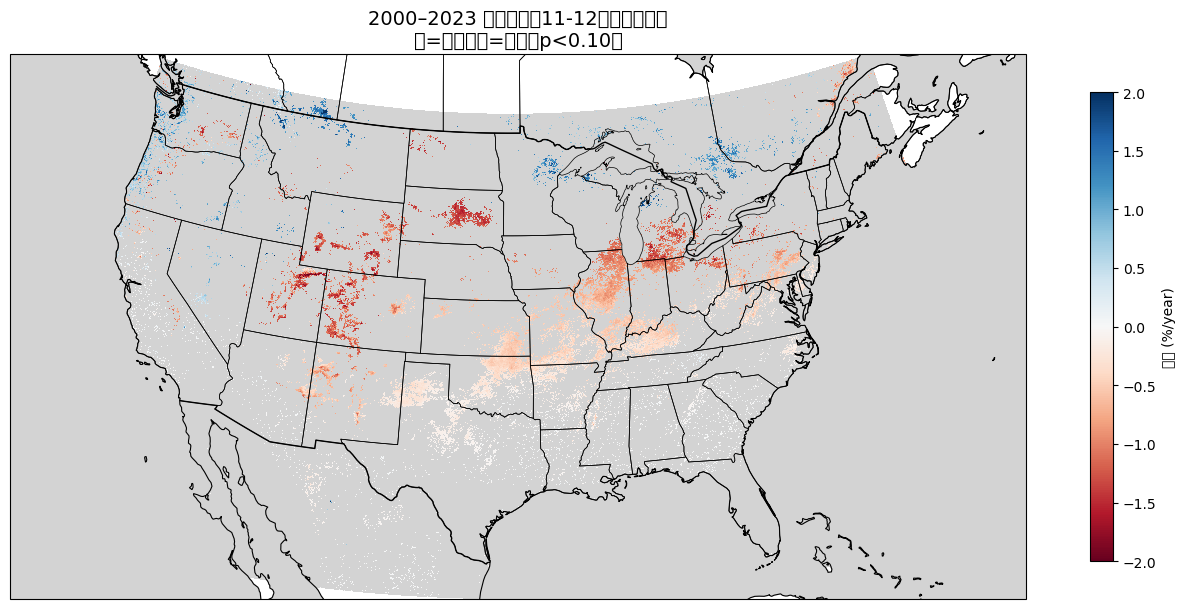

In [50]:
# ── Cell 8: 画早季趋势地图 ──
slope_sig = np.where(pval_map < 0.10, slope_map, np.nan)  # 用p<0.10（样本量小）

cmap_trend = plt.cm.RdBu
cmap_trend.set_bad(color='lightgray')

fig, ax = plt.subplots(figsize=(13, 7),
    subplot_kw={'projection': ccrs.LambertConformal(
        central_longitude=-96, central_latitude=39)})

im = ax.pcolormesh(lons, lats, slope_sig,
                   transform=ccrs.PlateCarree(),
                   cmap=cmap_trend, vmin=-2, vmax=2)

ax.add_feature(cfeature.OCEAN,     color='lightgray', zorder=1)
ax.add_feature(cfeature.STATES,    linewidth=0.5,     zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8,     zorder=2)
ax.add_feature(cfeature.BORDERS,   linewidth=1.0,     zorder=2)
ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())
ax.set_title('2000–2023 美国早季（11-12月）积雪趋势\n红=减少，蓝=增加（p<0.10）', fontsize=14)
plt.colorbar(im, ax=ax, label='趋势 (%/year)', shrink=0.7)

plt.tight_layout()
plt.savefig('early_season_trend_map.png', dpi=150, bbox_inches='tight')
plt.show()

# Hypothesis 3

In [1]:
# ── Cell 12: 批量计算湿球温度 & 统计造雪小时数 ──
import xarray as xr
import numpy as np
import os
import glob

era5_dir = os.path.expanduser('~/Final Project Computing/data/ERA5')
era5_files = sorted(glob.glob(f'{era5_dir}/era5_hourly_*.nc'))

# 湿球温度公式 (Stull 2011)
def wet_bulb(T_C, Td_C):
    """输入摄氏度，输出湿球温度（摄氏度）"""
    RH = 100 * np.exp((17.625 * Td_C) / (243.04 + Td_C)) / \
              np.exp((17.625 * T_C)  / (243.04 + T_C))
    RH = np.clip(RH, 0.1, 100)
    Tw = (T_C * np.arctan(0.151977 * (RH + 8.313659)**0.5)
        + np.arctan(T_C + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035)
    return Tw

# 用第一个文件获取经纬度坐标
ds0 = xr.open_dataset(era5_files[0])
era5_lats = ds0.latitude.values
era5_lons = ds0.longitude.values
ds0.close()

years_era5 = list(range(2000, 2026))
n_years    = len(years_era5)
n_lat_e    = len(era5_lats)
n_lon_e    = len(era5_lons)

# 存储每年11-12月造雪小时数（湿球温度 < -2°C 的小时数）
snowmaking_hours = np.full((n_years, n_lat_e, n_lon_e), np.nan, dtype=np.float32)

print("开始计算湿球温度...")
for i, (yr, fpath) in enumerate(zip(years_era5, era5_files)):
    ds = xr.open_dataset(fpath)

    # K → °C
    T_C  = ds['t2m'].values - 273.15
    Td_C = ds['d2m'].values - 273.15
    ds.close()

    # 计算湿球温度 (time, lat, lon)
    Tw = wet_bulb(T_C, Td_C)

    # 统计Tw < -2°C 的小时数
    snowmaking_hours[i] = np.sum(Tw < -2, axis=0).astype(np.float32)

    print(f"  {yr}: 完成，最大造雪小时数={np.nanmax(snowmaking_hours[i]):.0f}h")

print(f"\n✅ 全部完成！数组形状: {snowmaking_hours.shape}")

ERROR 1: PROJ: proj_create_from_database: Open of /opt/sw/anaconda3/2023.09/envs/pangeo23/share/proj failed


开始计算湿球温度...
  2000: 完成，最大造雪小时数=1464h
  2001: 完成，最大造雪小时数=1422h
  2002: 完成，最大造雪小时数=1460h
  2003: 完成，最大造雪小时数=1462h
  2004: 完成，最大造雪小时数=1424h
  2005: 完成，最大造雪小时数=1416h
  2006: 完成，最大造雪小时数=1434h
  2007: 完成，最大造雪小时数=1398h
  2008: 完成，最大造雪小时数=1403h
  2009: 完成，最大造雪小时数=1418h
  2010: 完成，最大造雪小时数=1415h
  2011: 完成，最大造雪小时数=1460h
  2012: 完成，最大造雪小时数=1403h
  2013: 完成，最大造雪小时数=1454h
  2014: 完成，最大造雪小时数=1409h
  2015: 完成，最大造雪小时数=1431h
  2016: 完成，最大造雪小时数=1348h
  2017: 完成，最大造雪小时数=1414h
  2018: 完成，最大造雪小时数=1454h
  2019: 完成，最大造雪小时数=1453h
  2020: 完成，最大造雪小时数=1405h
  2021: 完成，最大造雪小时数=1364h
  2022: 完成，最大造雪小时数=1456h
  2023: 完成，最大造雪小时数=1397h
  2024: 完成，最大造雪小时数=1439h
  2025: 完成，最大造雪小时数=1319h

✅ 全部完成！数组形状: (26, 105, 237)


/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:512: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  super()._update_title_position(renderer)
/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:512: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  super()._update_title_position(renderer)
/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:512: UserWarning: Glyph 36896 (\N{CJK UNIFIED IDEOGRAPH-9020}) missing from font(s) DejaVu Sans.
  super()._update_title_position(renderer)
/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:512: UserWarning: Glyph 38634 (\N{CJK UNIFIED IDEOGRAPH-96EA}) missing from font(s) DejaVu Sans.
  super()._update_title_position(renderer)
/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/car

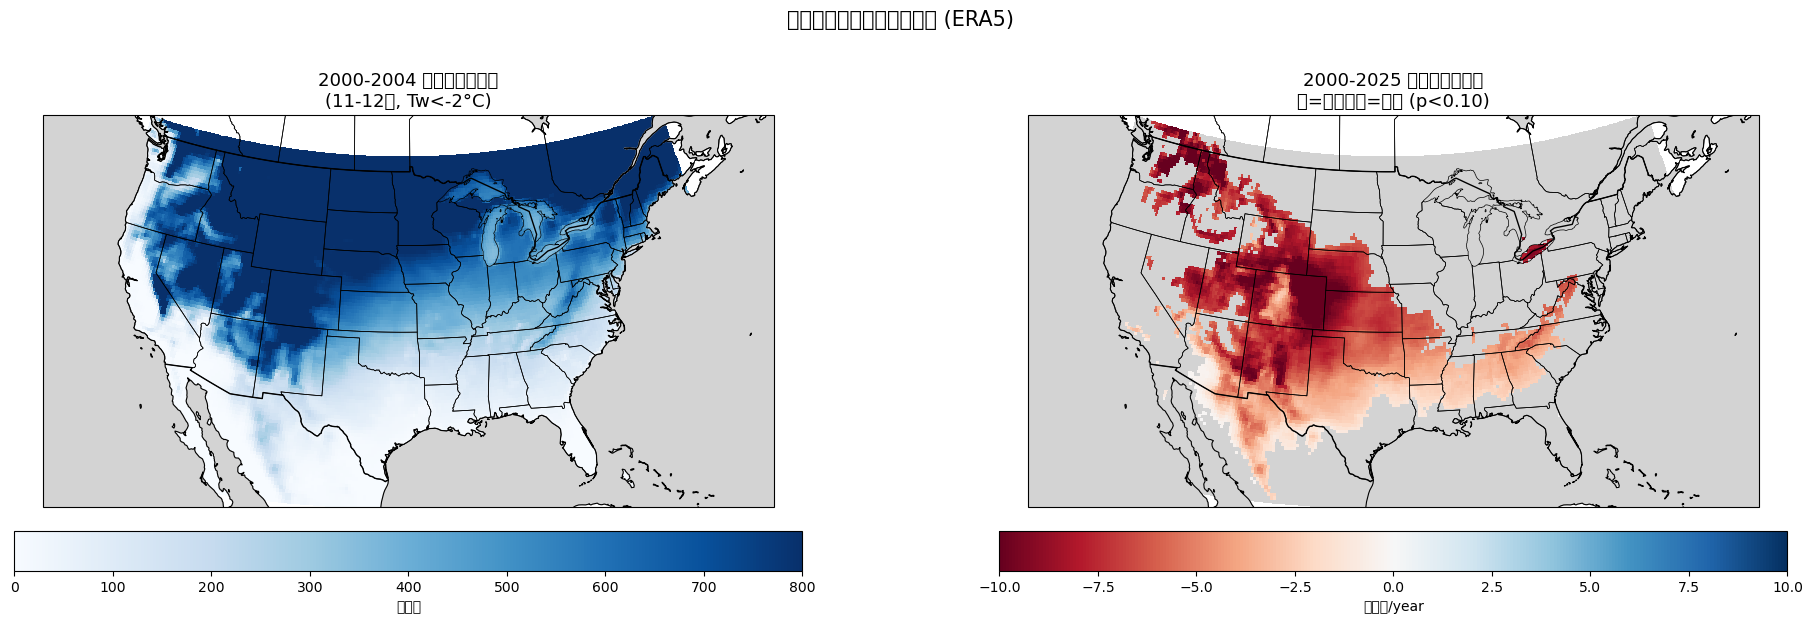

In [2]:
# ── Cell 13: 画造雪小时数趋势图 ──
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats

years_era5_arr = np.array(years_era5)

# 逐像素趋势
slope_sm  = np.full((n_lat_e, n_lon_e), np.nan)
pval_sm   = np.full((n_lat_e, n_lon_e), np.nan)

for i in range(n_lat_e):
    for j in range(n_lon_e):
        y     = snowmaking_hours[:, i, j]
        valid = ~np.isnan(y)
        if valid.sum() >= 10:
            slope, _, _, pval, _ = stats.linregress(years_era5_arr[valid], y[valid])
            slope_sm[i, j] = slope
            pval_sm[i, j]  = pval

# 只显示显著区域
slope_sig = np.where(pval_sm < 0.10, slope_sm, np.nan)

cmap_sm = plt.cm.RdBu
cmap_sm.set_bad(color='lightgray')

fig, axes = plt.subplots(1, 2, figsize=(20, 6),
    subplot_kw={'projection': ccrs.LambertConformal(
        central_longitude=-96, central_latitude=39)})

# 左图：2000-2004平均造雪小时数
early_sm = np.nanmean(snowmaking_hours[:5], axis=0)
im1 = axes[0].pcolormesh(era5_lons, era5_lats, early_sm,
                          transform=ccrs.PlateCarree(),
                          cmap='Blues', vmin=0, vmax=800)
axes[0].set_title('2000-2004 平均造雪小时数\n(11-12月, Tw<-2°C)', fontsize=13)
plt.colorbar(im1, ax=axes[0], label='小时数', orientation='horizontal',
             pad=0.05, shrink=0.8)

# 右图：趋势图
im2 = axes[1].pcolormesh(era5_lons, era5_lats, slope_sig,
                          transform=ccrs.PlateCarree(),
                          cmap=cmap_sm, vmin=-10, vmax=10)
axes[1].set_title('2000-2025 造雪小时数趋势\n红=减少，蓝=增加 (p<0.10)', fontsize=13)
plt.colorbar(im2, ax=axes[1], label='小时数/year', orientation='horizontal',
             pad=0.05, shrink=0.8)

for ax in axes:
    ax.add_feature(cfeature.OCEAN,     color='lightgray', zorder=1)
    ax.add_feature(cfeature.STATES,    linewidth=0.5,     zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8,     zorder=2)
    ax.add_feature(cfeature.BORDERS,   linewidth=1.0,     zorder=2)
    ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

plt.suptitle('美国早季潜在造雪条件变化 (ERA5)', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('snowmaking_trend.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_374130/1605903844.py:48: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_374130/1605903844.py:48: UserWarning: Glyph 20221 (\N{CJK UNIFIED IDEOGRAPH-4EFD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_374130/1605903844.py:48: UserWarning: Glyph 36896 (\N{CJK UNIFIED IDEOGRAPH-9020}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_374130/1605903844.py:48: UserWarning: Glyph 38634 (\N{CJK UNIFIED IDEOGRAPH-96EA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_374130/1605903844.py:48: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_374130/1605903844.py:48: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_374130/1605903844.py:48: UserWarning: Glyph 25968 (\N{CJK UNIFIED I

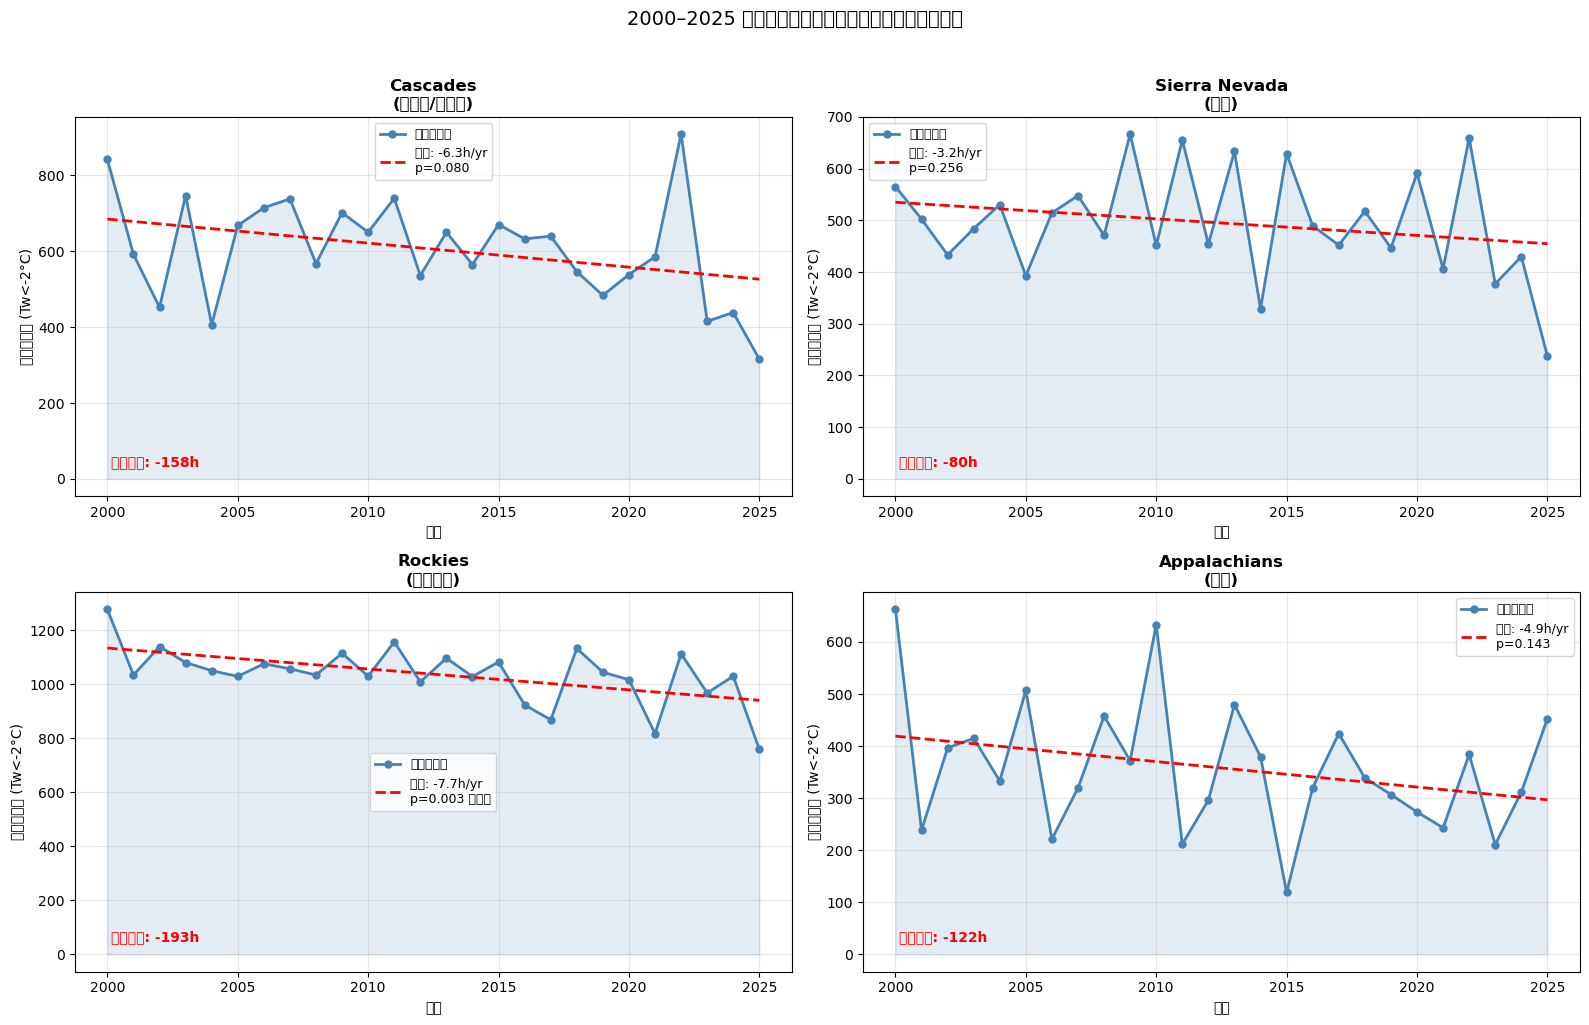

In [3]:
# ── Cell 14: 主要滑雪区域造雪小时数时间序列 ──
years_era5_arr = np.array(years_era5)

ski_regions_era5 = {
    'Cascades\n(华盛顿/俄勒冈)':  {'lat': (45, 49), 'lon': (-122, -120)},
    'Sierra Nevada\n(加州)':       {'lat': (36, 42), 'lon': (-121, -118)},
    'Rockies\n(科罗拉多)':         {'lat': (37, 41), 'lon': (-107, -104)},
    'Appalachians\n(东部)':        {'lat': (36, 42), 'lon': (-82,  -76)},
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (region_name, bounds) in zip(axes, ski_regions_era5.items()):
    lat_mask = (era5_lats >= bounds['lat'][0]) & (era5_lats <= bounds['lat'][1])
    lon_mask = (era5_lons >= bounds['lon'][0]) & (era5_lons <= bounds['lon'][1])

    ts = np.array([
        np.nanmean(snowmaking_hours[i][np.ix_(lat_mask, lon_mask)])
        for i in range(n_years)
    ])

    ax.plot(years_era5_arr, ts, 'o-', color='steelblue',
            linewidth=2, markersize=5, label='造雪小时数')
    ax.fill_between(years_era5_arr, ts, alpha=0.15, color='steelblue')

    # 趋势线
    valid = ~np.isnan(ts)
    slope, intercept, r, p, _ = stats.linregress(years_era5_arr[valid], ts[valid])
    color = 'red' if slope < 0 else 'green'
    ax.plot(years_era5_arr, slope * years_era5_arr + intercept,
            '--', color=color, linewidth=2,
            label=f'趋势: {slope:+.1f}h/yr\np={p:.3f} {"✅显著" if p<0.05 else ""}')

    # 累计变化标注
    total_change = slope * (years_era5_arr[-1] - years_era5_arr[0])
    ax.annotate(f'累计变化: {total_change:+.0f}h',
                xy=(0.05, 0.08), xycoords='axes fraction', fontsize=10,
                color=color, fontweight='bold')

    ax.set_title(region_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('年份')
    ax.set_ylabel('造雪小时数 (Tw<-2°C)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('2000–2025 美国主要滑雪区域早季潜在造雪小时数变化', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('snowmaking_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ── Cell 1: 从AWS下载4个山脉的Copernicus DEM tiles ──
import urllib.request
import os
import glob
import numpy as np
import subprocess

dem_dir = os.path.expanduser('~/Final Project Computing/data/DEM')
os.makedirs(dem_dir, exist_ok=True)

# 4个山脉需要的tile范围
ski_regions_bounds = {
    'Cascades':     {'lat': (45, 49), 'lon': (-122, -120)},
    'Sierra':       {'lat': (36, 42), 'lon': (-121, -118)},
    'Rockies':      {'lat': (37, 41), 'lon': (-107, -104)},
    'Appalachians': {'lat': (36, 42), 'lon': (-82,  -76)},
}

# 生成所有需要的tiles
all_tiles = set()
for region, bounds in ski_regions_bounds.items():
    for lat in range(bounds['lat'][0], bounds['lat'][1]+1):
        for lon in range(abs(bounds['lon'][1]), abs(bounds['lon'][0])+1):
            all_tiles.add((lat, lon))

print(f"共需下载 {len(all_tiles)} 个tiles")

# Copernicus DEM AWS路径格式
def get_cop_dem_url(lat, lon):
    lat_str = f'N{lat:02d}_00'
    lon_str = f'W{lon:03d}_00'
    name = f'Copernicus_DSM_COG_10_{lat_str}_{lon_str}_DEM'
    url  = f'https://copernicus-dem-30m.s3.amazonaws.com/{name}/{name}.tif'
    return url, name

success, skip, fail = 0, 0, 0
for lat, lon in sorted(all_tiles):
    url, name = get_cop_dem_url(lat, lon)
    save_path = os.path.join(dem_dir, f'{name}.tif')

    if os.path.exists(save_path):
        skip += 1
        continue

    try:
        urllib.request.urlretrieve(url, save_path)
        success += 1
        print(f"  ✅ {name}")
    except Exception as e:
        fail += 1

print(f"\n完成！成功:{success} 跳过:{skip} 失败:{fail}")

共需下载 112 个tiles
  ✅ Copernicus_DSM_COG_10_N36_00_W076_00_DEM
  ✅ Copernicus_DSM_COG_10_N36_00_W077_00_DEM
  ✅ Copernicus_DSM_COG_10_N36_00_W078_00_DEM
  ✅ Copernicus_DSM_COG_10_N36_00_W079_00_DEM
  ✅ Copernicus_DSM_COG_10_N36_00_W080_00_DEM
  ✅ Copernicus_DSM_COG_10_N36_00_W081_00_DEM
  ✅ Copernicus_DSM_COG_10_N36_00_W082_00_DEM
  ✅ Copernicus_DSM_COG_10_N36_00_W118_00_DEM
  ✅ Copernicus_DSM_COG_10_N36_00_W119_00_DEM
  ✅ Copernicus_DSM_COG_10_N36_00_W120_00_DEM
  ✅ Copernicus_DSM_COG_10_N36_00_W121_00_DEM
  ✅ Copernicus_DSM_COG_10_N37_00_W076_00_DEM
  ✅ Copernicus_DSM_COG_10_N37_00_W077_00_DEM
  ✅ Copernicus_DSM_COG_10_N37_00_W078_00_DEM
  ✅ Copernicus_DSM_COG_10_N37_00_W079_00_DEM
  ✅ Copernicus_DSM_COG_10_N37_00_W080_00_DEM
  ✅ Copernicus_DSM_COG_10_N37_00_W081_00_DEM
  ✅ Copernicus_DSM_COG_10_N37_00_W082_00_DEM
  ✅ Copernicus_DSM_COG_10_N37_00_W104_00_DEM
  ✅ Copernicus_DSM_COG_10_N37_00_W105_00_DEM
  ✅ Copernicus_DSM_COG_10_N37_00_W106_00_DEM
  ✅ Copernicus_DSM_COG_10_N37_00_W107_0

In [17]:
import os
import numpy as np
import rioxarray as rxr
from scipy.interpolate import RegularGridInterpolator

os.environ['PROJ_DATA'] = '/opt/sw/anaconda3/2023.09/envs/pangeo23/share/proj'
os.environ['PROJ_LIB']  = '/opt/sw/anaconda3/2023.09/envs/pangeo23/share/proj'

# ── 重新定义网格参数 ──
lat_min, lat_max =  24,   50
lon_min, lon_max = -125, -66

row_start = int((90 - lat_max) / 0.05)
row_end   = int((90 - lat_min) / 0.05)
col_start = int((lon_min + 180) / 0.05)
col_end   = int((lon_max + 180) / 0.05)

n_lat = row_end - row_start
n_lon = col_end - col_start

lats = np.arange(90, -90, -0.05)[row_start:row_end]
lons = np.arange(-180, 180, 0.05)[col_start:col_end]

dem_dir = os.path.expanduser('~/Final Project Computing/data/DEM')

print(f"n_lat={n_lat}, n_lon={n_lon}")
print(f"lats: {lats[-1]:.1f} ~ {lats[0]:.1f}")
print(f"lons: {lons[0]:.1f} ~ {lons[-1]:.1f}")

# ── 重新定义山脉范围 ──
ski_regions_bounds = {
    'Cascades':     {'lat': (45, 49), 'lon': (-122, -120)},
    'Sierra Nevada':{'lat': (36, 42), 'lon': (-121, -118)},
    'Rockies':      {'lat': (37, 41), 'lon': (-107, -104)},
    'Appalachians': {'lat': (36, 42), 'lon': (-82,  -76)},
}

# ── 初始化dem_modis ──
dem_modis = np.zeros((n_lat, n_lon), dtype=np.float32)

for region_name, bounds in ski_regions_bounds.items():
    print(f"\n处理 {region_name}...")

    region_tiles = []
    for lat in range(bounds['lat'][0], bounds['lat'][1]+1):
        for lon in range(abs(bounds['lon'][1]), abs(bounds['lon'][0])+1):
            pattern = os.path.join(dem_dir,
                f'Copernicus_DSM_COG_10_N{lat:02d}_00_W{lon:03d}_00_DEM.tif')
            if os.path.exists(pattern):
                region_tiles.append(pattern)

    print(f"  找到 {len(region_tiles)} 个tiles")
    if not region_tiles:
        continue

    tiles_data = []
    for f in region_tiles:
        da = rxr.open_rasterio(f, masked=True).squeeze()
        tiles_data.append(da)

    from rioxarray.merge import merge_arrays
    merged = merge_arrays(tiles_data)

    t_lats = merged.y.values
    t_lons = merged.x.values
    t_data = np.array(merged.values, dtype=np.float32)
    t_data = np.where(np.isnan(t_data), 0, t_data)
    t_data = np.where(t_data < 0, 0, t_data)

    print(f"  合并后形状: {t_data.shape}, 海拔: {t_data.min():.0f}~{t_data.max():.0f}m")

    if t_lats[0] > t_lats[-1]:
        t_lats = t_lats[::-1]
        t_data = t_data[::-1, :]

    lat_mask = (lats >= bounds['lat'][0]-0.1) & (lats <= bounds['lat'][1]+0.1)
    lon_mask = (lons >= bounds['lon'][0]-0.1) & (lons <= bounds['lon'][1]+0.1)

    region_lats = lats[lat_mask]
    region_lons = lons[lon_mask]
    grid_lon, grid_lat = np.meshgrid(region_lons, region_lats)

    interp = RegularGridInterpolator(
        (t_lats, t_lons), t_data,
        method='linear', bounds_error=False, fill_value=0
    )
    region_dem = interp((grid_lat, grid_lon)).astype(np.float32)

    lat_idx = np.where(lat_mask)[0]
    lon_idx = np.where(lon_mask)[0]
    dem_modis[np.ix_(lat_idx, lon_idx)] = region_dem

    print(f"  ✅ 插值完成，海拔: {region_dem.min():.0f}~{region_dem.max():.0f}m")

print(f"\n✅ 全部完成！dem_modis形状: {dem_modis.shape}")

n_lat=520, n_lon=1180
lats: 24.1 ~ 50.0
lons: -125.0 ~ -66.0

处理 Cascades...
  找到 15 个tiles
  合并后形状: (18000, 10800), 海拔: 0~4415m
  ✅ 插值完成，海拔: 0~4081m

处理 Sierra Nevada...
  找到 28 个tiles
  合并后形状: (25200, 14400), 海拔: 0~4411m
  ✅ 插值完成，海拔: 0~4089m

处理 Rockies...
  找到 20 个tiles
  合并后形状: (18000, 14400), 海拔: 1102~4396m
  ✅ 插值完成，海拔: 0~4132m

处理 Appalachians...
  找到 49 个tiles


MemoryError: Unable to allocate 49.4 MiB for an array with shape (3600, 3600) and data type float32